# AmanLeb — Data Exploration

This notebook is the first stage of the **AmanLeb** project, a multilingual AI system designed to detect spam and smishing messages with a focus on scams affecting users in Lebanon.

The goal of this notebook is to understand the raw SMS phishing dataset before building any machine learning model. We will inspect the dataset structure, examine the target classes, identify missing values and duplicates, study class imbalance, and visualize useful characteristics of the messages.

The dataset contains three target classes:

- **Ham** — legitimate messages
- **Spam** — unwanted or promotional messages
- **Smishing** — fraudulent SMS messages intended to deceive users or steal sensitive information

The main objectives of this exploratory analysis are:

1. Understand the dataset structure and available features.
2. Inspect the distribution of the target classes.
3. Detect missing values, duplicates, and possible data quality issues.
4. Explore important characteristics of the SMS messages.
5. Prepare the dataset for the classical machine learning pipeline.

The results of this notebook will guide the preprocessing and modeling decisions used in the next stage of AmanLeb.

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. CSV File Inspection

In [ ]:
df = pd.read_csv('Dataset_5971.csv')

In [ ]:
df.head()

,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Your opinion about me? 1. Over 2. Jada 3. Kusr...,No,No,No
1,ham,What's up? Do you want me to come online? If y...,No,No,No
2,ham,So u workin overtime nigpun?,No,No,No
3,ham,"Also sir, i sent you an email about how to log...",No,No,No
4,Smishing,Please Stay At Home. To encourage the notion o...,No,No,No


In [ ]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5971 entries, 0 to 5970
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   LABEL   5971 non-null   str  
 1   TEXT    5971 non-null   str  
 2   URL     5971 non-null   str  
 3   EMAIL   5971 non-null   str  
 4   PHONE   5971 non-null   str  
dtypes: str(5)
memory usage: 233.4 KB


,LABEL,TEXT,URL,EMAIL,PHONE
count,5971,5971,5971,5971,5971
unique,5,5949,2,2,2
top,ham,U have a secret admirer. REVEAL who thinks U R...,No,No,No
freq,4844,2,5764,5952,5127


## 3. Initial Dataset Inspection

The dataset contains 5,971 SMS messages and five columns: `LABEL`, `TEXT`, `URL`, `EMAIL`, and `PHONE`.

Initial inspection shows that there are no missing values. However, the target column contains five unique labels, although the intended classification problem consists of only three classes: Ham, Spam, and Smishing. This suggests possible inconsistencies in label formatting that should be investigated before cleaning.

The text column contains 5,949 unique messages out of 5,971 observations, indicating that duplicate or repeated messages may also be present.

Before modifying the dataset, the unique values and frequencies of each categorical column will be examined.

In [ ]:
df['LABEL'].unique()

<StringArray>
['ham', 'Smishing', 'spam', 'Spam', 'smishing']
Length: 5, dtype: str

In [ ]:
df['LABEL'].value_counts(dropna=False)

LABEL
ham         4844
Smishing     616
spam         466
Spam          23
smishing      22
Name: count, dtype: int64

In [ ]:
df['URL'].value_counts()

URL
No     5764
yes     207
Name: count, dtype: int64

In [ ]:
df['EMAIL'].value_counts()

EMAIL
No     5952
yes      19
Name: count, dtype: int64

In [ ]:
df['PHONE'].value_counts()

PHONE
No     5127
yes     844
Name: count, dtype: int64

In [ ]:
print("URL:", df['URL'].unique())
print("EMAIL:", df['EMAIL'].unique())
print("PHONE:", df['PHONE'].unique())

URL: <StringArray>
['No', 'yes']
Length: 2, dtype: str
EMAIL: <StringArray>
['No', 'yes']
Length: 2, dtype: str
PHONE: <StringArray>
['No', 'yes']
Length: 2, dtype: str


In [ ]:
df.duplicated().sum()

np.int64(17)

In [ ]:
df['TEXT'].duplicated().sum()

np.int64(22)

## 4. Data Quality Analysis and Cleaning

Initial inspection revealed several data quality issues that should be addressed before modeling.

The target variable contains five distinct string values instead of the expected three classes. This is caused by inconsistent capitalization, where `Spam` and `spam`, as well as `Smishing` and `smishing`, represent the same semantic classes.

The binary metadata features (`URL`, `EMAIL`, and `PHONE`) also use inconsistent capitalization (`No` and `yes`). These values will later be standardized and encoded numerically.

The dataset contains 17 fully duplicated rows and 22 duplicated message texts. Since the number of duplicated texts is larger than the number of completely duplicated rows, some identical SMS messages may contain different labels or metadata values. These cases should be investigated before duplicates are removed.

### 4.1 Standardize Class Labels

In [ ]:
df['LABEL'] = df['LABEL'].str.strip().str.lower()
df['LABEL'].value_counts()

LABEL
ham         4844
smishing     638
spam         489
Name: count, dtype: int64

### 4.2 Standardize Binary Metadata

In [ ]:
binary_columns = ['URL', 'EMAIL', 'PHONE']

for column in binary_columns:
    df[column] = df[column].str.strip().str.lower()

In [ ]:
for column in binary_columns:
    print(column)
    print(df[column].value_counts())
    print()

URL
URL
no     5764
yes     207
Name: count, dtype: int64

EMAIL
EMAIL
no     5952
yes      19
Name: count, dtype: int64

PHONE
PHONE
no     5127
yes     844
Name: count, dtype: int64



### 4.3 Investigate Duplicate Messages

In [ ]:
duplicate_texts = df[df.duplicated(subset='TEXT', keep=False)]

duplicate_texts.sort_values('TEXT')

,LABEL,TEXT,URL,EMAIL,PHONE
415,ham,Arun can u transfr me d amt,no,no,no
5343,ham,Arun can u transfr me d amt,no,no,no
3662,ham,Beautiful Truth against Gravity.. Read careful...,no,no,no
5094,ham,Beautiful Truth against Gravity.. Read careful...,no,no,no
3909,smishing,Congrats! 2 mobile 3G Videophones R yours. cal...,no,no,yes
1782,smishing,Congrats! 2 mobile 3G Videophones R yours. cal...,no,no,yes
5631,ham,"Do 1 thing! Change that sentence into: ""Becaus...",no,no,no
4515,ham,"Do 1 thing! Change that sentence into: ""Becaus...",no,no,no
4724,smishing,FREE MESSAGE Activate your 500 FREE Text Messa...,yes,no,yes
753,smishing,FREE MESSAGE Activate your 500 FREE Text Messa...,yes,no,no


In [ ]:
label_counts_per_text = df.groupby('TEXT')['LABEL'].nunique()

conflicting_texts = label_counts_per_text[label_counts_per_text > 1]

conflicting_texts

TEXT
Great News! Call FREEFONE 08006344447 to claim your guaranteed £1000 CASH or £2000 gift. Speak to a live operator NOW!                                   2
XXXMobileMovieClub: To use your credit, click the WAP link in the next txt message or click here>> http://wap. xxxmobilemovieclub.com?n=QJKGIGHJJGCBL    2
Name: LABEL, dtype: int64

In [ ]:
df[df['TEXT'].isin(conflicting_texts.index)].sort_values('TEXT')

,LABEL,TEXT,URL,EMAIL,PHONE
3569,smishing,Great News! Call FREEFONE 08006344447 to claim...,no,no,yes
3589,spam,Great News! Call FREEFONE 08006344447 to claim...,no,no,no
469,smishing,"XXXMobileMovieClub: To use your credit, click ...",yes,no,no
483,spam,"XXXMobileMovieClub: To use your credit, click ...",yes,no,no


In [ ]:
metadata_variation = (
    duplicate_texts
    .groupby('TEXT')[['URL', 'EMAIL', 'PHONE']]
    .nunique()
)

metadata_variation[
    (metadata_variation['URL'] > 1) |
    (metadata_variation['EMAIL'] > 1) |
    (metadata_variation['PHONE'] > 1)
]

,URL,EMAIL,PHONE
TEXT,,,
"FREE MESSAGE Activate your 500 FREE Text Messages by replying to this message with the word FREE For terms & conditions, visit www.07781482378.com",1,1,2
Great News! Call FREEFONE 08006344447 to claim your guaranteed £1000 CASH or £2000 gift. Speak to a live operator NOW!,1,1,2


### 4.4 Conflicting Duplicate Labels

Duplicate-message inspection revealed that two identical SMS messages were assigned different target labels (`spam` and `smishing`). Since identical input text should not have contradictory ground-truth labels, these observations represent label ambiguity or annotation noise.

Rather than arbitrarily selecting one of the conflicting labels, all occurrences of these conflicting messages will be excluded from the modeling dataset. This prevents contradictory examples from appearing across the training, validation, and test sets and preserves the integrity of the evaluation.

In [ ]:
df_clean = df[
    ~df['TEXT'].isin(conflicting_texts.index)
].copy()

In [ ]:
print("Original rows:", len(df))
print("After removing conflicting labels:", len(df_clean))

Original rows: 5971
After removing conflicting labels: 5967


In [ ]:
df_clean['TEXT'].duplicated().sum()

np.int64(20)

In [ ]:
df_clean = df_clean.drop_duplicates(
    subset='TEXT',
    keep='first'
).copy()

In [ ]:
df_clean.reset_index(drop=True, inplace=True)

In [ ]:
print("Final number of rows:", len(df_clean))
print()
print(df_clean['LABEL'].value_counts())


Final number of rows: 5947

LABEL
ham         4834
smishing     626
spam         487
Name: count, dtype: int64


### 4.5 Final Missing-Value Check for the Target Label

Although the initial dataset inspection did not reveal any Pandas-recognized null values in the `LABEL` column, missing information can sometimes be stored as ordinary strings such as `null`, `none`, `nan`, `missing`, or as empty whitespace.

A final validation is therefore performed to ensure that every observation contains a valid target label before continuing with exploratory analysis and modeling.

In [ ]:
# True missing values detected by pandas
df['LABEL'].isna().sum()

np.int64(0)

In [ ]:
(df['LABEL'].str.strip() == '').sum()

np.int64(0)

In [ ]:
missing_indicators = [
    'nan',
    'null',
    'none',
    'na',
    'n/a',
    'missing',
    'unknown',
    '?',
    '-'
]

In [ ]:
df[df['LABEL'].str.strip().str.lower().isin(missing_indicators)]

,LABEL,TEXT,URL,EMAIL,PHONE


In [ ]:
valid_labels = ['ham', 'spam', 'smishing']

In [ ]:
invalid_labels = df[~df['LABEL'].isin(valid_labels)]

invalid_labels

,LABEL,TEXT,URL,EMAIL,PHONE


In [ ]:
print("True NaN values:", df['LABEL'].isna().sum())
print("Empty labels:", (df['LABEL'].str.strip() == '').sum())
print(
    "Missing-indicator strings:",
    df['LABEL'].str.strip().str.lower().isin(missing_indicators).sum()
)
print(
    "Invalid labels:",
    (~df['LABEL'].isin(valid_labels)).sum()
)

True NaN values: 0
Empty labels: 0
Missing-indicator strings: 0
Invalid labels: 0


**Conclusion:** The `LABEL` column contains no true missing values, empty entries, placeholder strings, or invalid categories. After standardizing capitalization, all observations belong to one of the three expected classes: `ham`, `spam`, or `smishing`. The target variable is therefore considered clean and ready for further analysis.

## 5. Exploratory Data Analysis

After completing the data-cleaning stage, the cleaned dataset is explored to better understand its structure and the characteristics of the three target classes.

This section focuses on:

1. Class distribution and class imbalance.
2. Message length and word-count statistics.
3. Differences in message characteristics across Ham, Spam, and Smishing.
4. The relationship between the available metadata features (`URL`, `EMAIL`, and `PHONE`) and the target classes.

These observations will help guide the preprocessing and modeling decisions in later stages.

### 5.1 Class Distribution

In [ ]:
class_counts = df_clean['LABEL'].value_counts()
class_percentages = df_clean['LABEL'].value_counts(normalize=True) * 100

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages.round(2))

Class Counts:
LABEL
ham         4834
smishing     626
spam         487
Name: count, dtype: int64

Class Percentages:
LABEL
ham         81.28
smishing    10.53
spam         8.19
Name: proportion, dtype: float64


**Observation:** The dataset is imbalanced, with Ham messages representing the majority of observations. Spam and Smishing messages form much smaller classes. Therefore, accuracy alone may not provide a reliable evaluation of model performance, and class-specific metrics such as precision, recall, and F1-score will be important during evaluation.

### 5.2 Message Length Analysis

Two descriptive features are created from the message text:

- `CHAR_LENGTH`: number of characters in the message.
- `WORD_COUNT`: number of whitespace-separated words in the message.

These features are used for exploratory analysis to determine whether message length differs between Ham, Spam, and Smishing messages.

In [ ]:
df_clean['CHAR_LENGTH'] = df_clean['TEXT'].str.len()

df_clean['WORD_COUNT'] = df_clean['TEXT'].str.split().str.len()

In [ ]:
df_clean[['TEXT', 'CHAR_LENGTH', 'WORD_COUNT']].head()

,TEXT,CHAR_LENGTH,WORD_COUNT
0,Your opinion about me? 1. Over 2. Jada 3. Kusr...,136,26
1,What's up? Do you want me to come online? If y...,79,17
2,So u workin overtime nigpun?,28,5
3,"Also sir, i sent you an email about how to log...",173,33
4,Please Stay At Home. To encourage the notion o...,152,24


**Observation:** Spam and Smishing messages generally contain more characters and words than Ham messages. Their median message lengths are noticeably higher than that of Ham messages. However, there is substantial overlap between the three distributions, indicating that message length alone would not be sufficient to reliably classify an SMS.

Several very long Ham messages also appear as statistical outliers. These observations are not removed automatically because unusual message length does not necessarily indicate invalid data.

### 5.3 Descriptive Statistics by Class

In [ ]:
df_clean.groupby('LABEL')[['CHAR_LENGTH', 'WORD_COUNT']].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(2)

CHAR_LENGTH                                WORD_COUNT                \
               count    mean median    std min  max      count   mean median   
LABEL                                                                          
ham             4834   70.68   53.0  56.17   2  910       4834  14.16   11.0   
smishing         626  139.62  146.0  32.60  34  383        626  22.82   24.0   
spam             487  133.90  143.0  34.25  18  379        487  23.02   24.0   

                          
            std min  max  
LABEL                     
ham       11.10   1  171  
smishing   5.92   5   68  
spam       6.60   2   61

### 5.4 Message Length by Class

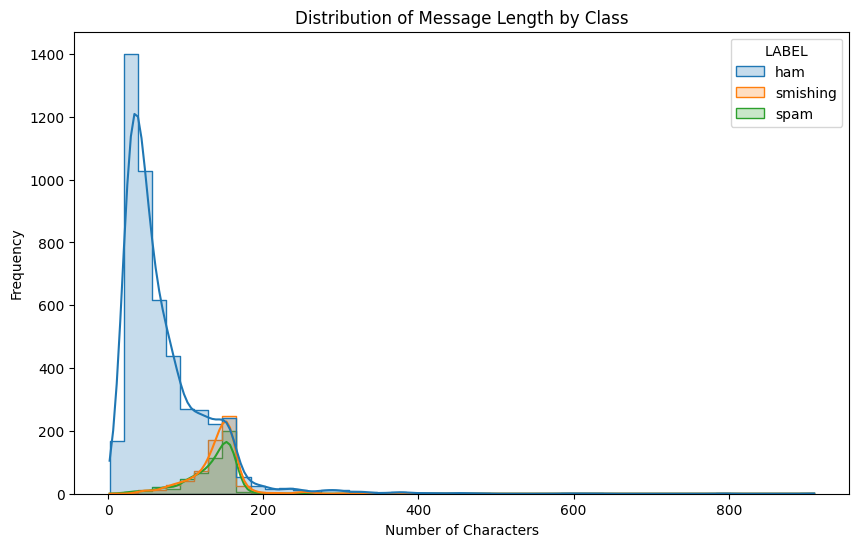

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x='CHAR_LENGTH',
    hue='LABEL',
    bins=50,
    kde=True,
    element='step'
)

plt.title('Distribution of Message Length by Class')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')

plt.show()

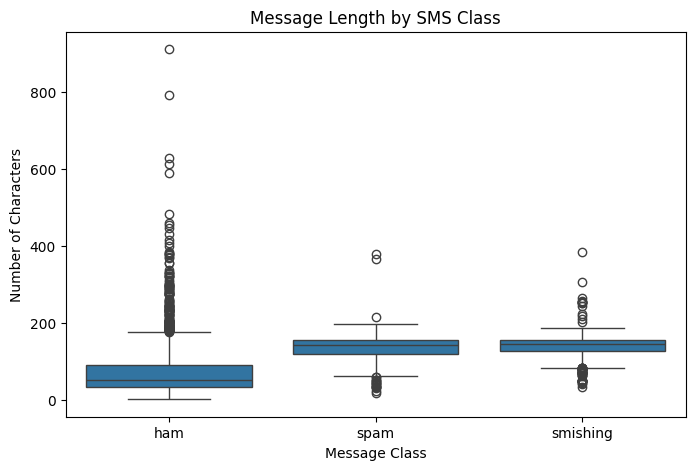

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='LABEL',
    y='CHAR_LENGTH',
    order=['ham', 'spam', 'smishing']
)

plt.title('Message Length by SMS Class')
plt.xlabel('Message Class')
plt.ylabel('Number of Characters')

plt.show()

### 5.5 Word Count by Class

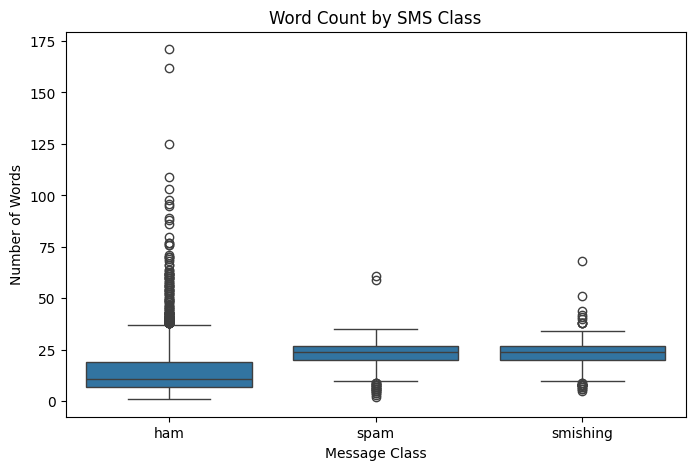

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='LABEL',
    y='WORD_COUNT',
    order=['ham', 'spam', 'smishing']
)

plt.title('Word Count by SMS Class')
plt.xlabel('Message Class')
plt.ylabel('Number of Words')

plt.show()

### 5.6 URL, Email, and Phone Features

In [ ]:
for feature in ['URL', 'EMAIL', 'PHONE']:
    print(f"\n{feature} distribution by class:")
    
    display(
        pd.crosstab(
            df_clean['LABEL'],
            df_clean[feature],
            normalize='index'
        ).round(3) * 100
    )


URL distribution by class:


URL,no,yes
LABEL,,
ham,99.8,0.2
smishing,84.3,15.7
spam,79.9,20.1



EMAIL distribution by class:


EMAIL,no,yes
LABEL,,
ham,100.0,0.0
smishing,98.2,1.8
spam,98.6,1.4



PHONE distribution by class:


PHONE,no,yes
LABEL,,
ham,99.9,0.1
smishing,17.6,82.4
spam,36.3,63.7


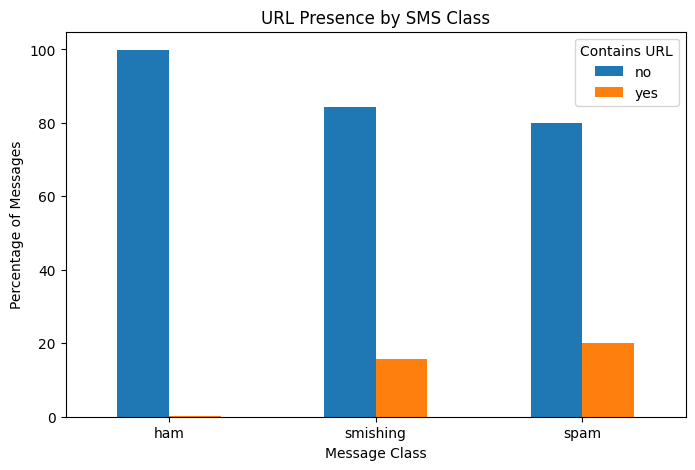

In [ ]:
url_by_class = pd.crosstab(
    df_clean['LABEL'],
    df_clean['URL'],
    normalize='index'
) * 100

url_by_class.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('URL Presence by SMS Class')
plt.xlabel('Message Class')
plt.ylabel('Percentage of Messages')
plt.xticks(rotation=0)
plt.legend(title='Contains URL')

plt.show()

In [ ]:
for feature in ['URL', 'EMAIL', 'PHONE']:
    print(f"\nClass distribution given {feature}:")
    
    display(
        (
            pd.crosstab(
                df_clean['LABEL'],
                df_clean[feature],
                normalize='columns'
            ) * 100
        ).round(2)
    )


Class distribution given URL:


URL,no,yes
LABEL,,
ham,84.03,3.92
smishing,9.19,48.04
spam,6.77,48.04



Class distribution given EMAIL:


EMAIL,no,yes
LABEL,,
ham,81.53,5.26
smishing,10.37,57.89
spam,8.10,36.84



Class distribution given PHONE:


PHONE,no,yes
LABEL,,
ham,94.39,0.84
smishing,2.15,61.94
spam,3.46,37.21


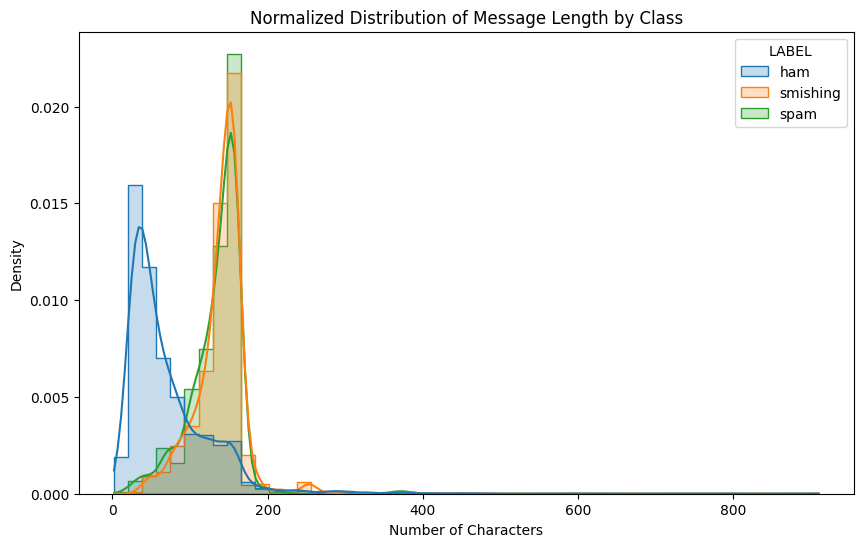

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x='CHAR_LENGTH',
    hue='LABEL',
    bins=50,
    stat='density',
    common_norm=False,
    kde=True,
    element='step'
)

plt.title('Normalized Distribution of Message Length by Class')
plt.xlabel('Number of Characters')
plt.ylabel('Density')

plt.show()

#### Message length contains useful information for distinguishing Ham from malicious/unwanted messages, but it appears much less useful for distinguishing Spam from Smishing.

## 6. Save and Verify the Cleaned Dataset

Only the original cleaned columns (`LABEL`, `TEXT`, `URL`, `EMAIL`, and `PHONE`) are saved for modeling. The helper features `CHAR_LENGTH` and `WORD_COUNT` were created only for exploratory analysis and are intentionally excluded from the modeling dataset.


In [ ]:
columns_to_save = ['LABEL', 'TEXT', 'URL', 'EMAIL', 'PHONE']

df_clean[columns_to_save].to_csv(
    'Dataset_5971_clean.csv',
    index=False
)

In [ ]:
print(df_clean.shape)
df_clean.head()

(5947, 7)


,LABEL,TEXT,URL,EMAIL,PHONE,CHAR_LENGTH,WORD_COUNT
0,ham,Your opinion about me? 1. Over 2. Jada 3. Kusr...,no,no,no,136,26
1,ham,What's up? Do you want me to come online? If y...,no,no,no,79,17
2,ham,So u workin overtime nigpun?,no,no,no,28,5
3,ham,"Also sir, i sent you an email about how to log...",no,no,no,173,33
4,smishing,Please Stay At Home. To encourage the notion o...,no,no,no,152,24


## 7. Final EDA Conclusion

The exploratory data analysis and cleaning process provided a clear understanding of the SMS phishing dataset and identified several important considerations for the modeling stage.

The original dataset contained inconsistencies in label capitalization, duplicate messages, and a small number of identical messages with conflicting `spam` and `smishing` labels. These issues were investigated and cleaned before further analysis. A final validation also confirmed that the target column contained no true missing values, empty labels, placeholder missing-value strings, or invalid classes.

The cleaned dataset remains strongly imbalanced. Approximately **81.28%** of the messages are Ham, compared with **10.53% Smishing** and **8.19% Spam**. As a result, model performance should not be judged using accuracy alone. Precision, recall, F1-score, macro-averaged metrics, and confusion matrices will be especially important when evaluating the minority Spam and Smishing classes.

Message-length analysis showed that Spam and Smishing messages tend to contain more characters and words than Ham messages. After normalizing the distributions to account for class imbalance, Ham messages were concentrated at shorter lengths, while Spam and Smishing showed similar distributions centered at longer messages. However, substantial overlap exists between the classes, meaning that message length alone is not sufficient for reliable classification. Several unusually long Ham messages were also observed, demonstrating why statistical outliers should not automatically be treated as invalid observations.

The structural metadata features showed strong relationships with the target classes. URL and phone-number presence were rare in Ham messages but considerably more common in Spam and Smishing messages. Among messages containing a URL, approximately **96% belonged to either Spam or Smishing**. Phone-number presence showed an even stronger pattern: among messages containing a phone number, approximately **61.94% were Smishing, 37.21% were Spam, and only 0.84% were Ham**. Email presence showed a similar tendency toward suspicious classes, although only a very small number of messages contained email addresses, so this observation should be interpreted cautiously.

Overall, the EDA suggests that simple structural characteristics can provide useful signals for distinguishing ordinary Ham messages from suspicious messages. However, these features provide considerably less separation between Spam and Smishing, and the distributions of the classes still overlap substantially.

Therefore, the next stage of AmanLeb will focus on analyzing the **actual textual content of each message**. The message text will be transformed into numerical features using **TF-IDF**, followed by a **Logistic Regression classifier** to establish the first classical machine learning baseline for Ham, Spam, and Smishing detection.